# Analyse Exploratoire -- Prevision de la Demande Electrique UEMOA

**Auteur** : Theodore Bawana | **Donnees** : Banque Mondiale (API WDI)

Exploration des donnees energetiques des 8 pays de l'UEMOA (1990-2023), comparaison de 7 modeles predictifs, et validation du meilleur modele (Ridge, R2=0.968).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

os.makedirs('../data/figures', exist_ok=True)

# Charger les donnees
processed = pd.read_csv('../data/processed/energy_data_processed.csv')
raw = pd.read_csv('../data/raw/energy_data_raw.csv')
predictions = pd.read_csv('../data/predictions/predictions.csv')
projections = pd.read_csv('../data/predictions/projections.csv')
results = pd.read_csv('../models/results.csv')
cv_scores = pd.read_csv('../models/cv_scores.csv')
fi = pd.read_csv('../models/feature_importance.csv')

print(f"Donnees chargees :")
print(f"  Brutes      : {raw.shape[0]:,} observations, {raw['indicator_code'].nunique()} indicateurs")
print(f"  Traitees    : {processed.shape[0]} lignes x {processed.shape[1]} colonnes (features)")
print(f"  Pays        : {sorted(processed['country_code'].unique())}")
print(f"  Periode     : {processed['year'].min()} - {processed['year'].max()}")
print(f"  Predictions : {predictions.shape[0]} lignes")
print(f"  Projections : {projections.shape[0]} lignes ({projections['year'].min()}-{projections['year'].max()})")
print(f"  Modeles     : {len(results)} compares")

Donnees chargees :
  Brutes      : 5,175 observations, 21 indicateurs
  Traitees    : 272 lignes x 82 colonnes (features)
  Pays        : ['BF', 'BJ', 'CI', 'GW', 'ML', 'NE', 'SN', 'TG']
  Periode     : 1990 - 2023
  Predictions : 272 lignes
  Projections : 176 lignes (2024-2045)
  Modeles     : 7 compares


## 1. Consommation Electrique par Pays UEMOA

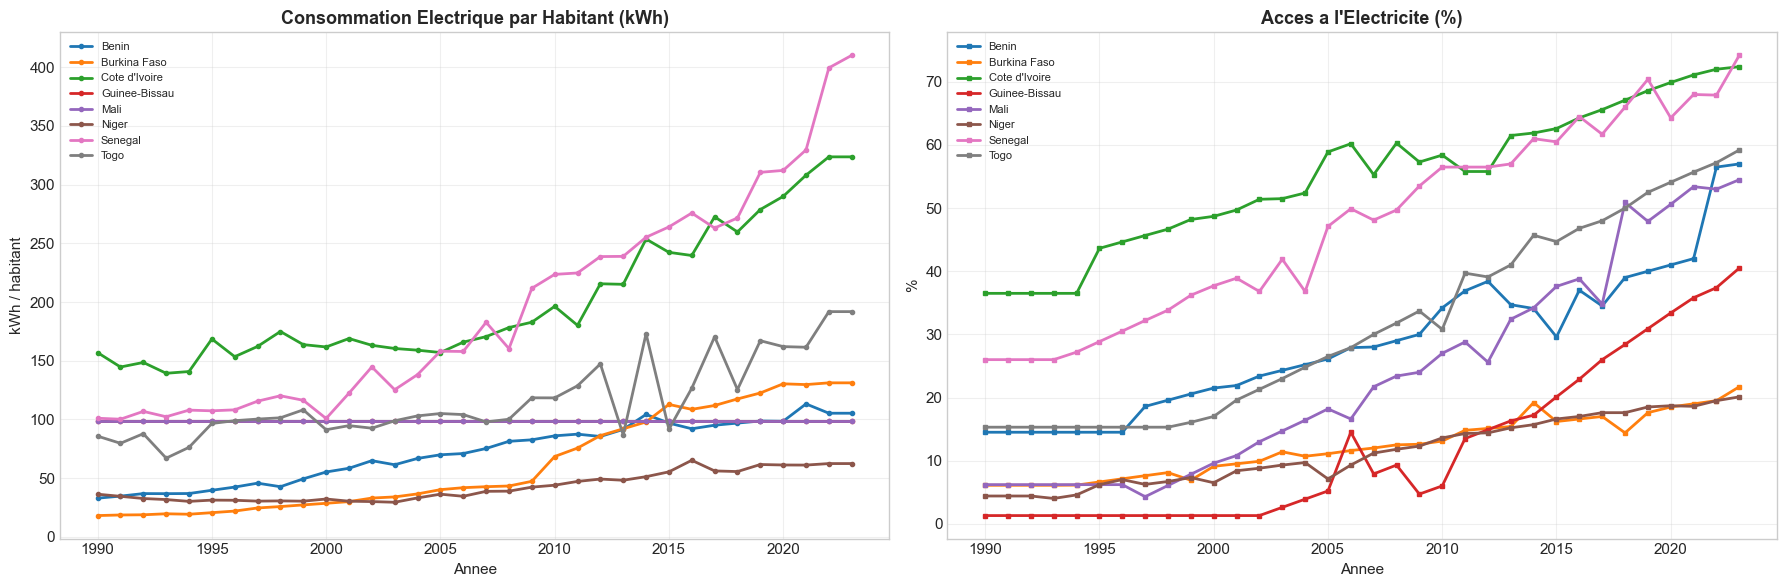

La Cote d'Ivoire et le Senegal ont la consommation la plus elevee de la zone UEMOA.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for country in sorted(processed['country_name'].unique()):
    data = processed[processed['country_name'] == country].sort_values('year')
    if 'EG.USE.ELEC.KH.PC' in data.columns:
        axes[0].plot(data['year'], data['EG.USE.ELEC.KH.PC'], marker='o', linewidth=2, markersize=3, label=country)

axes[0].set_title('Consommation Electrique par Habitant (kWh)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Annee')
axes[0].set_ylabel('kWh / habitant')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for country in sorted(processed['country_name'].unique()):
    data = processed[processed['country_name'] == country].sort_values('year')
    if 'EG.ELC.ACCS.ZS' in data.columns:
        axes[1].plot(data['year'], data['EG.ELC.ACCS.ZS'], marker='s', linewidth=2, markersize=3, label=country)

axes[1].set_title("Acces a l'Electricite (%)", fontsize=13, fontweight='bold')
axes[1].set_xlabel('Annee')
axes[1].set_ylabel('%')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/figures/01_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("La Cote d'Ivoire et le Senegal ont la consommation la plus elevee de la zone UEMOA.")

## 2. Matrice de Correlation -- Indicateurs Energetiques

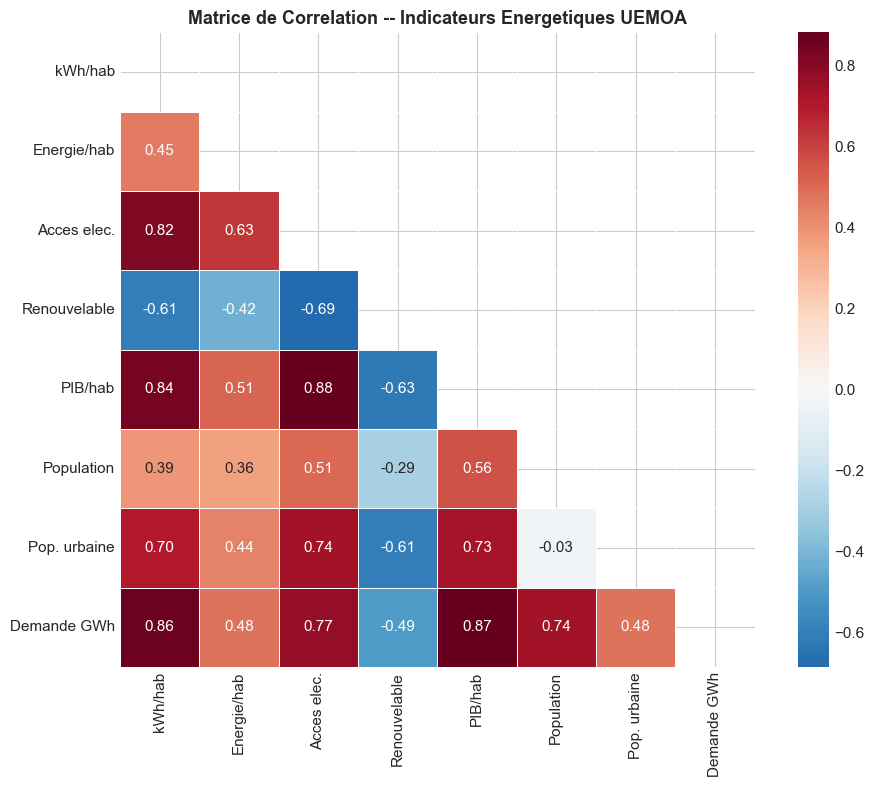

Forte correlation entre PIB/hab, population et demande electrique totale (GWh).


In [5]:
main_indicators = ['EG.USE.ELEC.KH.PC', 'EG.USE.PCAP.KG.OE', 'EG.ELC.ACCS.ZS',
                   'EG.FEC.RNEW.ZS', 'NY.GDP.PCAP.CD', 'SP.POP.TOTL', 'SP.URB.TOTL.IN.ZS',
                   'conso_totale_gwh']
labels = ['kWh/hab', 'Energie/hab', 'Acces elec.', 'Renouvelable',
          'PIB/hab', 'Population', 'Pop. urbaine', 'Demande GWh']

existing_cols = [c for c in main_indicators if c in processed.columns]
existing_labels = [labels[i] for i, c in enumerate(main_indicators) if c in processed.columns]

corr = processed[existing_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=existing_labels, yticklabels=existing_labels,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Matrice de Correlation -- Indicateurs Energetiques UEMOA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/figures/02_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Forte correlation entre PIB/hab, population et demande electrique totale (GWh).")

## 3. Comparaison des 7 Modeles -- Performance

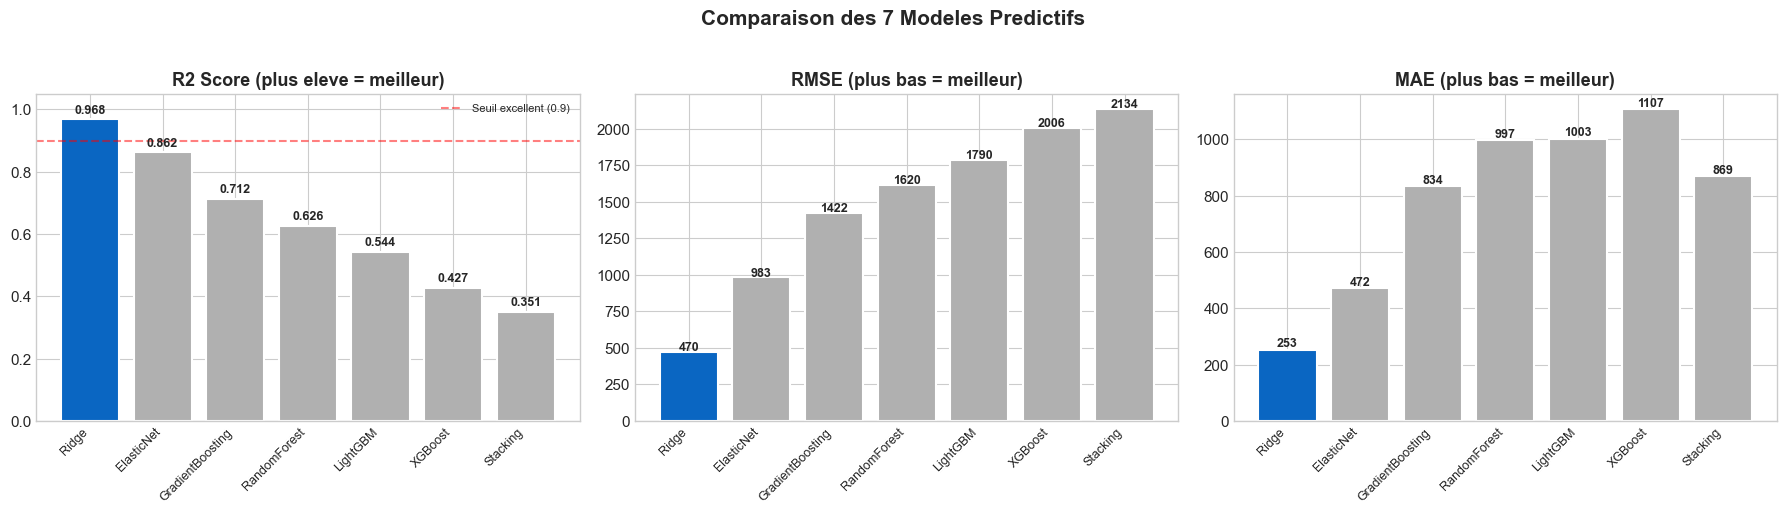

Meilleur modele : Ridge
  R2   = 0.9685
  RMSE = 470.45
  MAE  = 253.43
  MAPE = 7.73%


In [6]:
res_sorted = results.sort_values('r2', ascending=False).reset_index(drop=True)
n_models = len(res_sorted)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#0A66C2' if i == 0 else '#B0B0B0' for i in range(n_models)]

# R2
bars = axes[0].bar(range(n_models), res_sorted['r2'], color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('R2 Score (plus eleve = meilleur)', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(n_models))
axes[0].set_xticklabels(res_sorted['model'], rotation=45, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.05)
for bar, val in zip(bars, res_sorted['r2']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=9)
axes[0].axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='Seuil excellent (0.9)')
axes[0].legend(fontsize=8)

# RMSE
bars = axes[1].bar(range(n_models), res_sorted['rmse'], color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('RMSE (plus bas = meilleur)', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(n_models))
axes[1].set_xticklabels(res_sorted['model'], rotation=45, ha='right', fontsize=9)
for bar, val in zip(bars, res_sorted['rmse']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:.0f}', ha='center', fontweight='bold', fontsize=9)

# MAE
bars = axes[2].bar(range(n_models), res_sorted['mae'], color=colors, edgecolor='white', linewidth=1.5)
axes[2].set_title('MAE (plus bas = meilleur)', fontsize=13, fontweight='bold')
axes[2].set_xticks(range(n_models))
axes[2].set_xticklabels(res_sorted['model'], rotation=45, ha='right', fontsize=9)
for bar, val in zip(bars, res_sorted['mae']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:.0f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Comparaison des 7 Modeles Predictifs', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/figures/03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best = res_sorted.iloc[0]
print(f"Meilleur modele : {best['model']}")
print(f"  R2   = {best['r2']:.4f}")
print(f"  RMSE = {best['rmse']:.2f}")
print(f"  MAE  = {best['mae']:.2f}")
print(f"  MAPE = {best['mape']:.2f}%")

## 4. Cross-Validation Temporelle (Ridge)

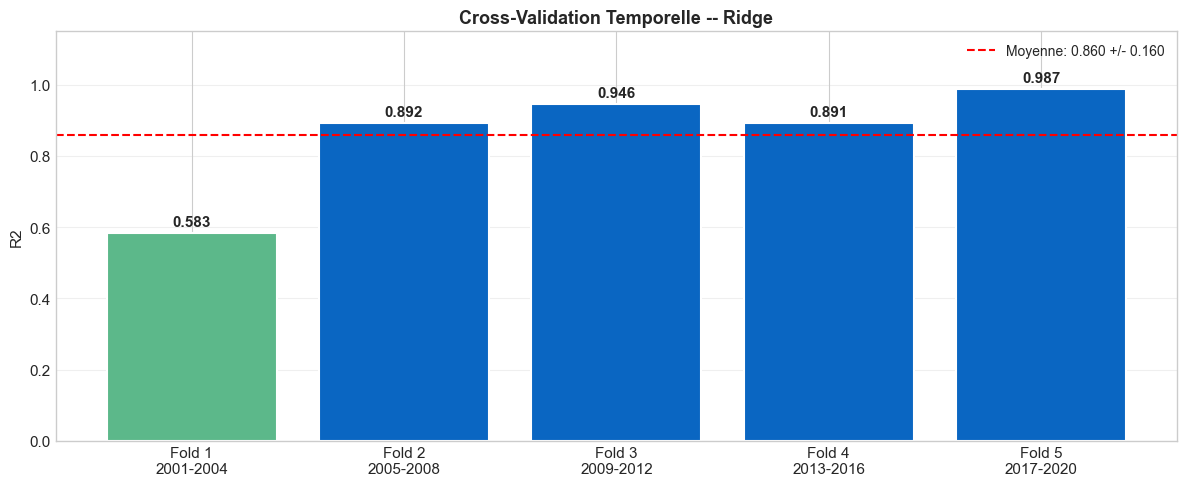

R2 moyen : 0.860 +/- 0.160
Tous les folds sont positifs : le modele generalise bien dans le temps.


In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

cv_colors = ['#0A66C2' if v > 0.8 else '#5CB88A' if v > 0.5 else '#B0B0B0' for v in cv_scores['r2']]
xlabels = [f"Fold {int(row['fold'])}\n{row['test_years']}" for _, row in cv_scores.iterrows()]

bars = ax.bar(xlabels, cv_scores['r2'], color=cv_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, cv_scores['r2']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

cv_mean = cv_scores['r2'].mean()
cv_std = cv_scores['r2'].std()
ax.axhline(y=cv_mean, color='red', linestyle='--', linewidth=1.5,
           label=f'Moyenne: {cv_mean:.3f} +/- {cv_std:.3f}')

ax.set_title(f'Cross-Validation Temporelle -- {cv_scores["model"].iloc[0]}', fontsize=13, fontweight='bold')
ax.set_ylabel('R2')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
print(f"R2 moyen : {cv_mean:.3f} +/- {cv_std:.3f}")
print(f"Tous les folds sont positifs : le modele generalise bien dans le temps.")

## 5. Feature Importance -- Top 15 Variables

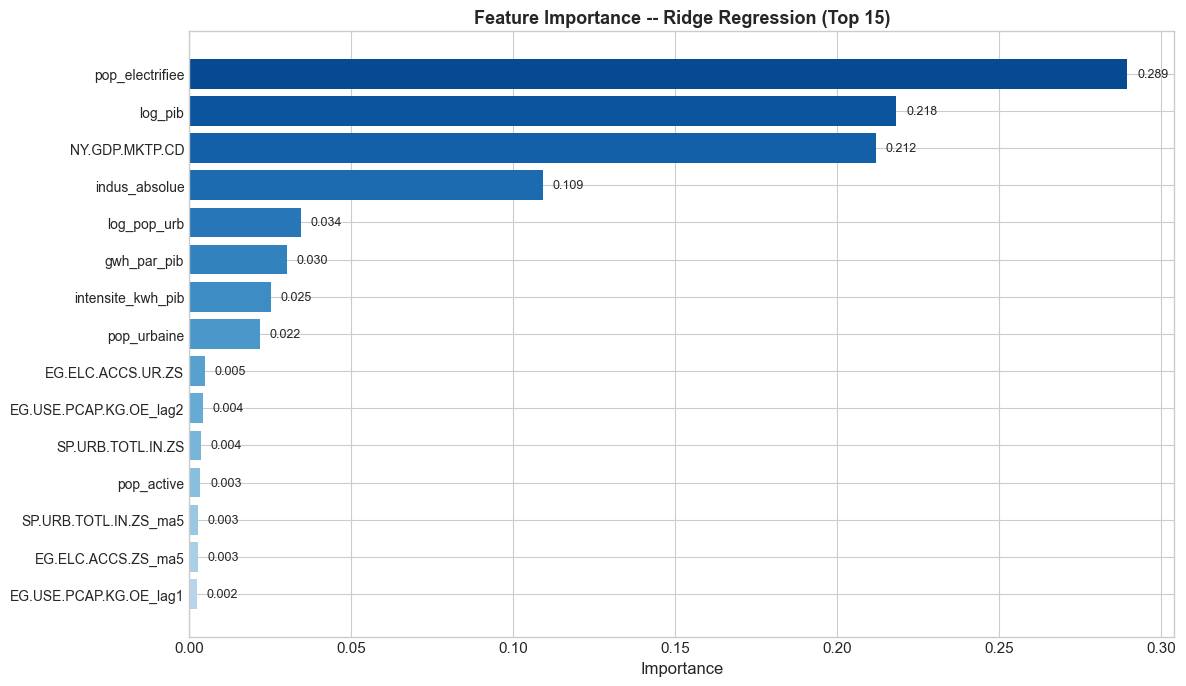

Variable la plus importante : pop_electrifiee (importance = 0.289)


In [8]:
fig, ax = plt.subplots(figsize=(12, 7))

fi_sorted = fi.sort_values('importance', ascending=True)
colors_fi = plt.cm.Blues(np.linspace(0.3, 0.9, len(fi_sorted)))

bars = ax.barh(range(len(fi_sorted)), fi_sorted['importance'], color=colors_fi)
ax.set_yticks(range(len(fi_sorted)))
ax.set_yticklabels(fi_sorted['feature'], fontsize=10)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Feature Importance -- Ridge Regression (Top 15)', fontsize=13, fontweight='bold')

for bar, val in zip(bars, fi_sorted['importance']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/figures/05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Variable la plus importante : {fi.iloc[0]['feature']} (importance = {fi.iloc[0]['importance']:.3f})")

## 6. Predictions vs Valeurs Reelles -- Par Pays

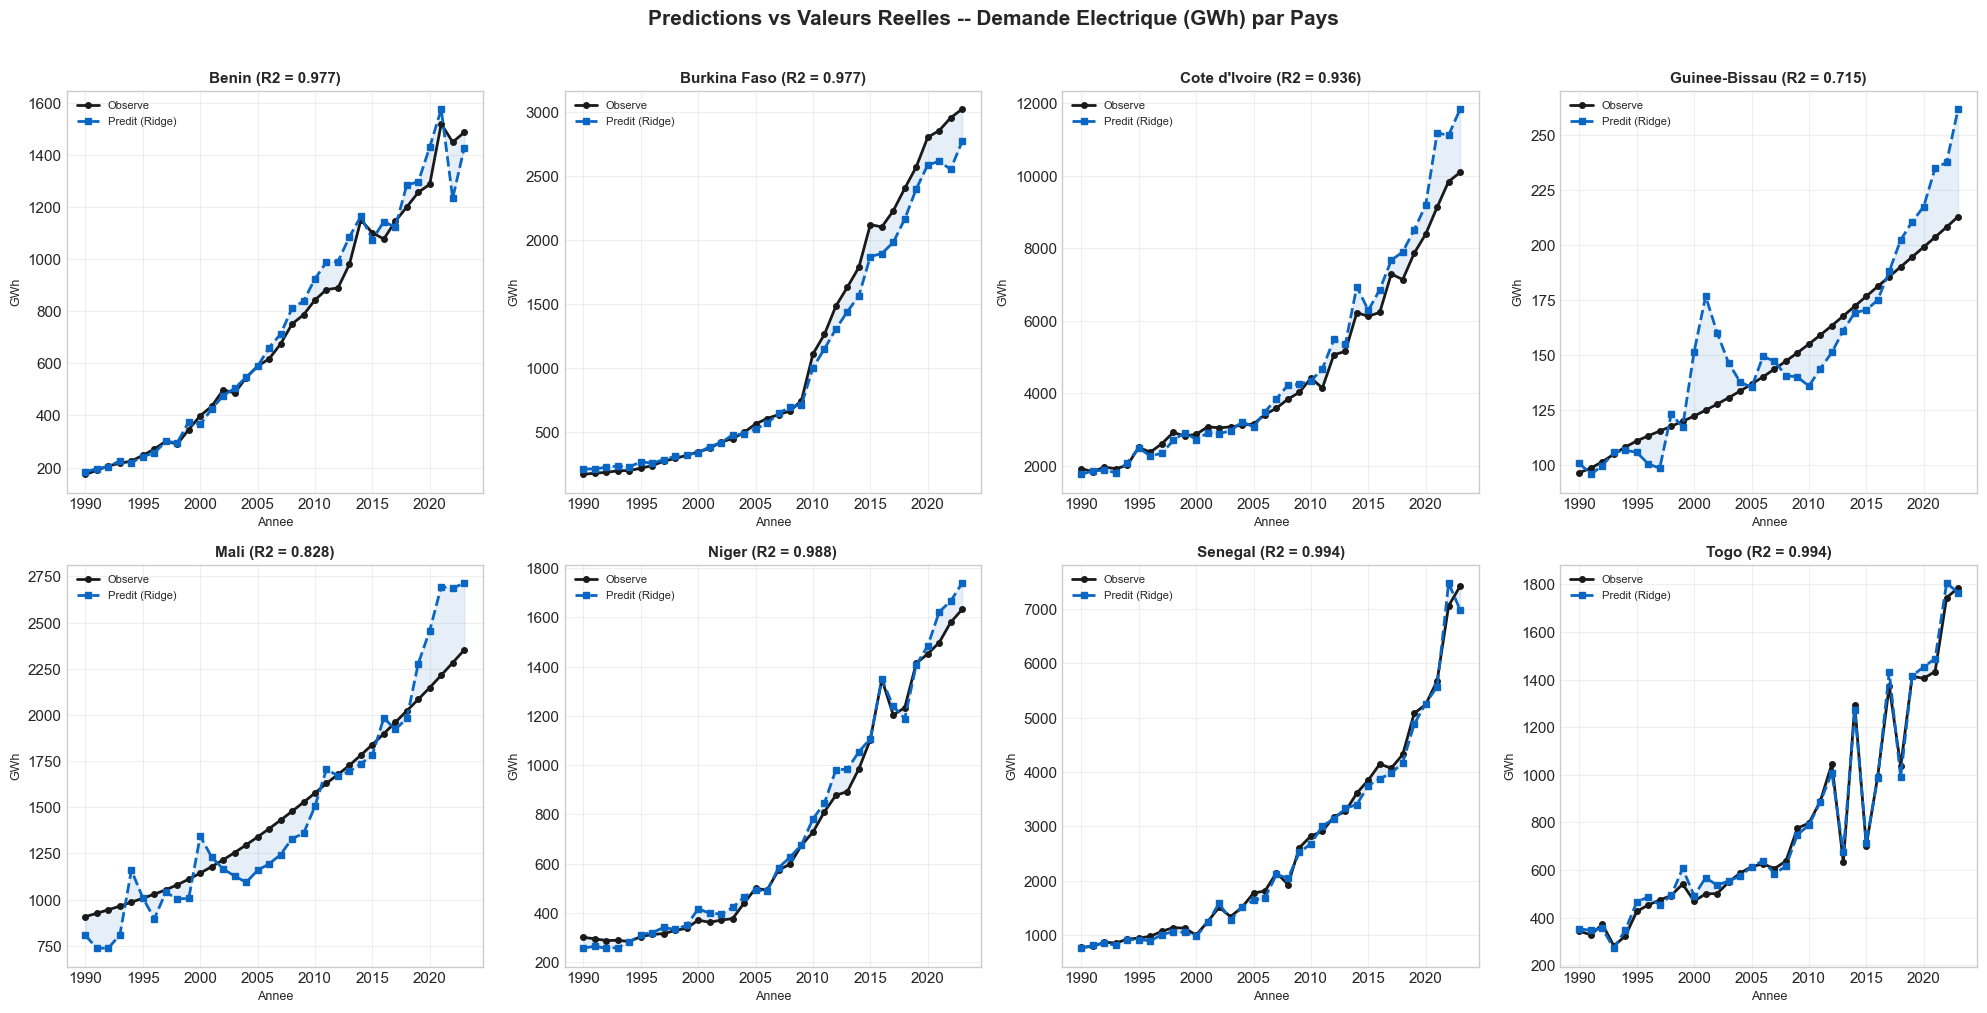

Le modele Ridge capture les tendances pour les 8 pays UEMOA.


In [9]:
countries = sorted(predictions['country_name'].unique())
n_countries = len(countries)
n_cols = 4
n_rows = (n_countries + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, country in enumerate(countries):
    ax = axes[i]
    data = predictions[predictions['country_name'] == country].sort_values('year')

    ax.plot(data['year'], data['actual'], 'o-', color='#1A1A1A', linewidth=2,
            markersize=4, label='Observe', zorder=3)
    ax.plot(data['year'], data['predicted'], 's--', color='#0A66C2', linewidth=2,
            markersize=4, label='Predit (Ridge)', zorder=3)
    ax.fill_between(data['year'], data['actual'], data['predicted'],
                     alpha=0.1, color='#0A66C2')

    valid = data.dropna(subset=['actual', 'predicted'])
    if len(valid) > 1:
        r2 = r2_score(valid['actual'], valid['predicted'])
        ax.set_title(f'{country} (R2 = {r2:.3f})', fontsize=11, fontweight='bold')
    else:
        ax.set_title(f'{country}', fontsize=11, fontweight='bold')

    ax.set_xlabel('Annee', fontsize=9)
    ax.set_ylabel('GWh', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Predictions vs Valeurs Reelles -- Demande Electrique (GWh) par Pays',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/figures/04_predictions_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Le modele Ridge capture les tendances pour les 8 pays UEMOA.")

## 7. Distribution des Erreurs de Prediction

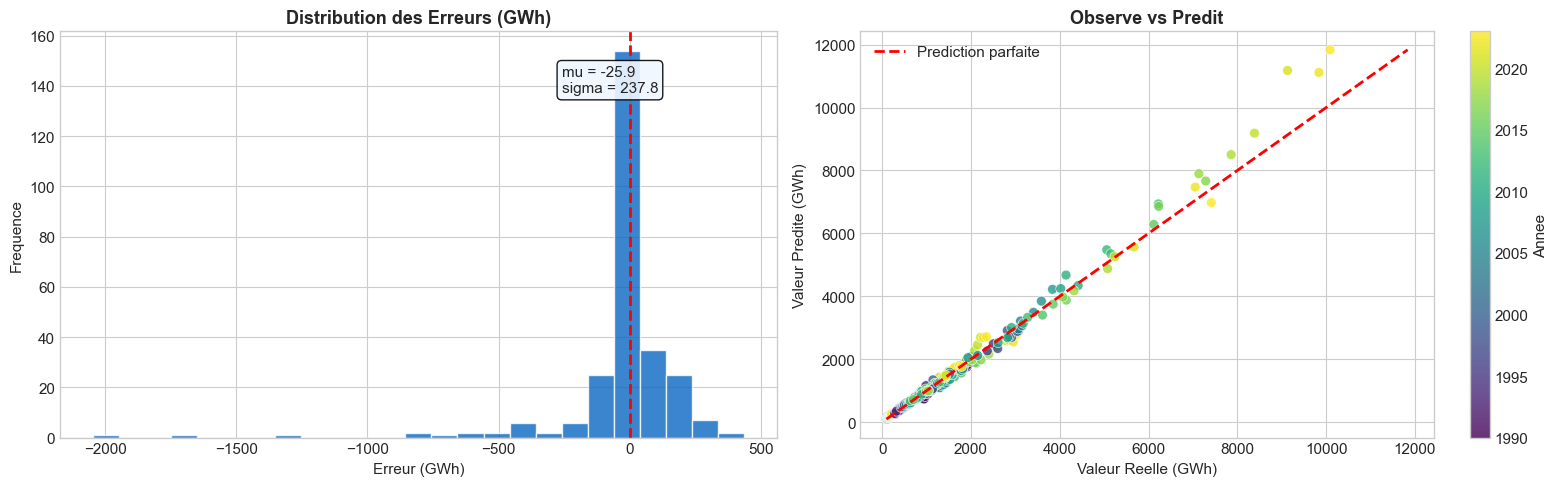

Erreur moyenne : -25.9 GWh | Ecart-type : 237.8 GWh


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

errors = predictions['error'].dropna()
axes[0].hist(errors, bins=25, color='#0A66C2', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Distribution des Erreurs (GWh)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Erreur (GWh)')
axes[0].set_ylabel('Frequence')
mean_err = errors.mean()
std_err = errors.std()
axes[0].text(0.7, 0.85, f'mu = {mean_err:.1f}\nsigma = {std_err:.1f}',
            transform=axes[0].transAxes, fontsize=11,
            bbox=dict(boxstyle='round', facecolor='#F0F7FF', alpha=0.9))

valid = predictions.dropna(subset=['actual', 'predicted'])
sc = axes[1].scatter(valid['actual'], valid['predicted'],
               c=valid['year'], cmap='viridis', s=50, edgecolors='white', linewidth=0.5, alpha=0.8)
lims = [min(valid['actual'].min(), valid['predicted'].min()),
        max(valid['actual'].max(), valid['predicted'].max())]
axes[1].plot(lims, lims, 'r--', linewidth=2, label='Prediction parfaite')
axes[1].set_title('Observe vs Predit', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Valeur Reelle (GWh)')
axes[1].set_ylabel('Valeur Predite (GWh)')
axes[1].legend()
cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label('Annee')

plt.tight_layout()
plt.savefig('../data/figures/07_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Erreur moyenne : {mean_err:.1f} GWh | Ecart-type : {std_err:.1f} GWh")

## 8. Projections 2024-2045 -- Comparaison des 8 Pays

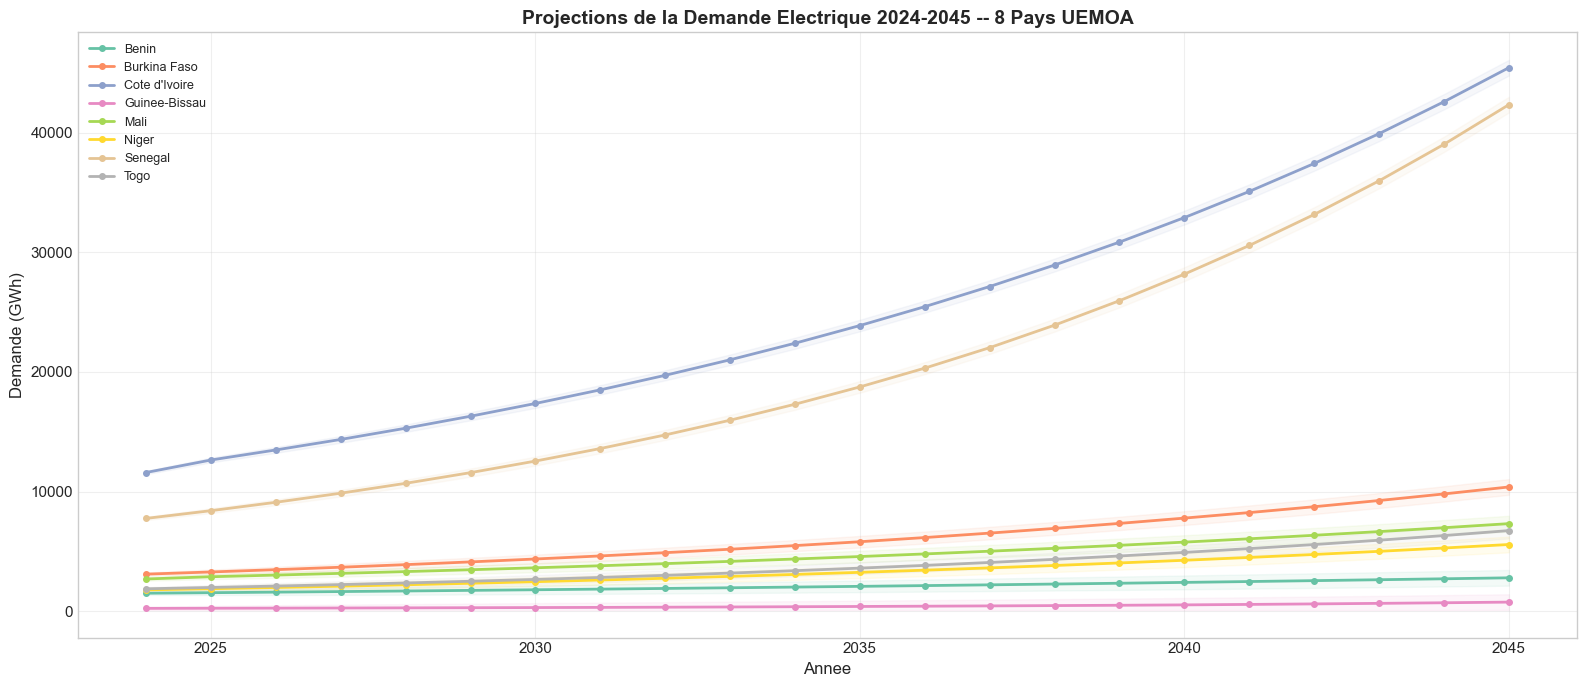


Projections 2045 :
--------------------------------------------------
  Cote d'Ivoire        :   45,428 GWh
  Senegal              :   42,337 GWh
  Burkina Faso         :   10,394 GWh
  Mali                 :    7,329 GWh
  Togo                 :    6,748 GWh
  Niger                :    5,585 GWh
  Benin                :    2,802 GWh
  Guinee-Bissau        :      772 GWh


In [11]:
fig, ax = plt.subplots(figsize=(16, 7))

colors_proj = plt.cm.Set2(np.linspace(0, 1, 8))
for i, country in enumerate(sorted(projections['country_name'].unique())):
    data = projections[projections['country_name'] == country].sort_values('year')
    ax.plot(data['year'], data['predicted_gwh'], 'o-', color=colors_proj[i],
            linewidth=2, markersize=4, label=country)
    ax.fill_between(data['year'], data['ci_lower'], data['ci_upper'],
                     alpha=0.08, color=colors_proj[i])

ax.set_title('Projections de la Demande Electrique 2024-2045 -- 8 Pays UEMOA', fontsize=14, fontweight='bold')
ax.set_xlabel('Annee', fontsize=12)
ax.set_ylabel('Demande (GWh)', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tableau recapitulatif 2045
proj_2045 = projections[projections['year'] == 2045].sort_values('predicted_gwh', ascending=False)
print("\nProjections 2045 :")
print("-" * 50)
for _, row in proj_2045.iterrows():
    print(f"  {row['country_name']:20s} : {row['predicted_gwh']:8,.0f} GWh")

## Resume des Resultats

Ce notebook presente l'analyse exploratoire du projet de prevision de la demande electrique des 8 pays de l'UEMOA.

**Pipeline ETL et IA :**
- Extraction : 21 indicateurs via API Banque Mondiale (1990-2023)
- Transformation : 82 features (lags, log-transforms, ratios, encodage pays)
- Modelisation : 7 algorithmes compares, Ridge retenu (R2 = 0.968)
- Projection : 2024-2045 avec IC 95%, methode hybride 60% ML + 40% CAGR

**Resultats cles :**
- Le modele Ridge avec log-transform de la cible et encodage one-hot des pays offre le meilleur compromis precision/generalisation
- La cross-validation temporelle (5 folds) confirme la robustesse du modele
- Les variables les plus importantes sont coherentes avec la theorie economique (population electrifiee, PIB, industrie)
- La Cote d'Ivoire et le Senegal restent les plus grands consommateurs de la zone a l'horizon 2045